# Assignment: Building a Tiny Transformer That Learns Addition

## Overview

In this assignment you will implement a minimal GPT-style Transformer inspired by:

- The Tiny Transformer walkthrough notebook
- Andrej Karpathy's nanoGPT / miniGPT style training loops
- The `projects/adder` sequence modeling idea

Your model will learn to solve integer addition problems such as:

```text
12+35=47
```

and later generalize to unseen:

```text
384+217=601
```

The assignment is intentionally structured in milestones so that you build the system incrementally and debug each layer independently.

# Learning Goals

By the end of this assignment you should be able to:

1. Build a tokenizer and character vocabulary
2. Generate autoregressive training data
3. Implement causal self-attention from scratch
4. Assemble a Transformer block
5. Train a tiny GPT-like language model
6. Generate predictions autoregressively
7. Evaluate model quality using real mathematical checks

# Problem Setup

We will train a character-level Transformer.

Input examples:

```text
12+7=19
```

```text
384+217=601
```

The model learns one next-character prediction at a time.

Example training sequence:

```text
1 2 + 7 = 1 9
```

Targets are shifted by one token:

```text
2 + 7 = 1 9 <END>
```

This is exactly the same autoregressive training strategy used by GPT models.

# Starter Imports


In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import random
import math

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


# Milestone 1 — Tokenizer & Dataset

## Goal

Build:

- vocabulary
- tokenizer
- dataset generator
- batching logic

## Step 1 — Generate Addition Problems
Complete the function.

In [2]:
import random

# Generate zero-padded addition problems.
# Format: 03+76=079\n  (always 2 digits per operand, 3 digits for result)
#
# WHY THIS MATTERS: without padding, the model sees "3" and has no way to
# know whether the next character is "+" (A=3, single digit) or another
# digit (A=30-39, two digits). This ambiguity propagates to the answer
# and is the reason loss stalls at ~1.1 no matter how long we train.
# With padding, every character position has a fixed meaning:
#   pos 0-1: operand A  |  pos 2: "+"  |  pos 3-4: operand B
#   pos 5: "="          |  pos 6-8: result  |  pos 9: "\n"
def generate_example(max_digits=2):
    max_val = 10**max_digits - 1
    a = random.randint(0, max_val)
    b = random.randint(0, max_val)
    c = a + b
    return f"{a:0{max_digits}d}+{b:0{max_digits}d}={c:0{max_digits+1}d}\n"

## Step 2 — Build a Dataset String

Generate many training examples.

In [3]:
# Create a long training string containing many examples

train_text = ""

for _ in range(50000):
    train_text += generate_example()

print(train_text[:200])

81+14=095
03+94=097
35+31=066
28+17=045
94+13=107
86+94=180
69+11=080
75+54=129
04+03=007
11+27=038
29+64=093
77+03=080
71+25=096
91+83=174
89+69=158
53+28=081
57+75=132
35+00=035
97+20=117
89+54=143



## Step 3 — Build Vocabulary

Extract all unique characters.

Typical vocabulary:
```python
['\n', '+', '0', '1', '2', ..., '9', '=']
```

Complete the tokenizer.

In [4]:
# 1. Find unique chars
chars = sorted(list(set(train_text)))
vocab_size = len(chars)

# 2. Build stoi dictionary
stoi = {ch: i for i, ch in enumerate(chars)}
# 3. Build itos dictionary
itos = {i: ch for i, ch in enumerate(chars)}


def encode(s):
    """Encodes a string into a list of integers."""
    return [stoi[ch] for ch in s]


def decode(tokens):
    """Decodes a list of integers into a string."""
    return "".join([itos[ix] for ix in tokens])

print(f"Vocabulary: {chars}")
print(f"Vocabulary size: {vocab_size}")

Vocabulary: ['\n', '+', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=']
Vocabulary size: 13


## Step 4 — Convert Dataset to Tokens

In [5]:
# Convert the text dataset into integer tokens

data = torch.tensor(encode(train_text), dtype=torch.long)

print(data[:20])

tensor([10,  3,  1,  3,  6, 12,  2, 11,  7,  0,  2,  5,  1, 11,  6, 12,  2, 11,
         9,  0])


## Step 5 — Create Batch Loader

The model learns next-token prediction.

Targets are shifted by one character.

In [6]:
batch_size = 64
block_size = 40   # matches clean-slate: 4 complete zero-padded problems (10 chars each) per window

def get_batch(split='train'):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    X = torch.stack([data[i:i+block_size] for i in ix])
    Y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return X.to(device), Y.to(device)

## Verification Cell

Run this before moving on.


In [7]:
X, Y = get_batch()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("Decoded sample:")
print(decode(X[0].tolist()))

print("Target sample:")
print(decode(Y[0].tolist()))

X shape: torch.Size([64, 40])
Y shape: torch.Size([64, 40])
Decoded sample:
+74=105
71+29=100
40+92=132
97+50=147
86
Target sample:
74=105
71+29=100
40+92=132
97+50=147
86+


Expected behavior:

- `Y` is `X` shifted by one character
- decoded text looks like valid addition expressions

# Milestone 2 — Causal Multi-Head Attention

## Goal

Implement masked self-attention.

This is the core idea behind GPT.

Each token:

- looks at previous tokens
- cannot see future tokens

# Step 1 — Single Attention Head

Complete the module.

In [8]:
class Head(nn.Module):

    def __init__(self, input_dim, head_size):
        super().__init__()

        # Key, query, and value projections
        self.key = nn.Linear(input_dim, head_size, bias=False)
        self.query = nn.Linear(input_dim, head_size, bias=False)
        self.value = nn.Linear(input_dim, head_size, bias=False)

        # Register causal mask buffer
        self.register_buffer(
            'tril',
            torch.tril(torch.ones(block_size, block_size))
        )

    def forward(self, x):

        B, T, C = x.shape

        # Compute keys, queries, values
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)

        # Attention scores ( "affinities" )
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        weights = q @ k.transpose(-2, -1)

        # Scale attention scores
        weights = weights * (k.shape[-1] ** -0.5)   # k.shape[-1] = head_size

        # IMPORTANT:
        # Apply causal mask
        weights = weights.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        # Softmax
        weights = F.softmax(weights, dim=-1)

        # Return weighted aggregation of values
        out = weights @ v # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)

        return out

## Step 2 — Multi-Head Attention

In [9]:
class MultiHeadAttention(nn.Module):

    def __init__(self, n_embd, num_heads, head_size, dropout):
        super().__init__()

        # Create multiple attention heads
        self.heads = nn.ModuleList([Head(n_embd, head_size) for _ in range(num_heads)])
        # Linear layer to project the concatenated outputs
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):

        # Concatenate outputs from each head
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Project the concatenated output back to n_embd dimensions
        out = self.attn_dropout(self.proj(out))

        return out

## Verification Cell

In [10]:
x = torch.randn(4, block_size, 64) # Note: n_embd is 64 based on suggested hyperparameters

# Assuming n_embd is globally available or passed to Head
n_embd = 64 # Temporary, as n_embd will be defined in TinyGPT

head = Head(n_embd, 16)
out = head(x)

print(out.shape)

torch.Size([4, 40, 16])


Expected output:
```python
torch.Size([4, block_size, 16])
```

# Milestone 3 — Transformer Block & Training Loop

## Goal

Build:

- Feed-forward network
- Layer normalization
- Residual connections
- Full Transformer block
- GPT model
- Training loop

# Step 1 — Feed Forward Network


In [11]:
class FeedForward(nn.Module):

    def __init__(self, n_embd, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),                    # GELU outperforms ReLU for transformer arithmetic tasks
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# Step 2 — Transformer Block

Use:

- attention
- feed forward
- layer norm
- residual connections

In [12]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head, dropout):
        super().__init__()

        head_size = n_embd // n_head

        # Multi-Head Attention
        self.sa = MultiHeadAttention(n_embd, n_head, head_size, dropout)
        # Feed Forward Network
        self.ffwd = FeedForward(n_embd, dropout)
        # Layer Normalization
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        # Residual connections and Layer Normalization
        x = x + self.sa(self.ln1(x))    # attention applied once
        x = x + self.ffwd(self.ln2(x))  # feed-forward applied once

        return x

# Step 3 — Complete GPT Model

In [13]:
class TinyGPT(nn.Module):

    def __init__(self, n_embd, n_head, n_layer, dropout=0.1):
        super().__init__()

        # Hyperparameters
        global vocab_size # Get vocab_size from the global context

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.dropout_emb = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head, dropout=dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # Final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = self.dropout_emb(tok_emb + pos_emb) # (B,T,C) with dropout on embeddings
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        loss = None

        if targets is not None:
            # Reshape logits for loss calculation, but keep original for return
            logits_for_loss = logits.view(B*T, logits.shape[-1])
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits_for_loss, targets)

        return logits, loss

# Step 4 — Create Model

In [24]:
n_embd       = 64
n_head       = 4
n_layer      = 3     # matches clean-slate (was 2; the extra block is needed for carrying)
dropout_rate = 0.0   # addition is deterministic; no regularization needed

model = TinyGPT(n_embd=n_embd, n_head=n_head, n_layer=n_layer, dropout=dropout_rate).to(device)

print(sum(p.numel() for p in model.parameters()) / 1e6, 'M parameters')

0.153741 M parameters


In [15]:
# ============================================================
# CLEAN-SLATE TRAINING CELL  (zero-padded format)
# Run this single cell to train a fresh model from scratch.
# Self-contained: re-seeds, re-generates data, redefines all
# classes, trains, and evaluates — ignores all kernel state.
# ============================================================

import torch, torch.nn as nn, random
from torch.nn import functional as F
import re as _re

torch.manual_seed(42)
random.seed(42)
_device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- zero-padded data: 03+76=079\n  (always 10 chars) ---
def _gen():
    a, b = random.randint(0, 99), random.randint(0, 99)
    return f"{a:02d}+{b:02d}={a+b:03d}\n"

_text  = "".join(_gen() for _ in range(50000))
_chars = sorted(set(_text))
_vs    = len(_chars)
_stoi  = {c: i for i, c in enumerate(_chars)}
_itos  = {i: c for i, c in enumerate(_chars)}
_enc   = lambda s: [_stoi[c] for c in s]
_dec   = lambda t: "".join(_itos[i] for i in t)
_data  = torch.tensor(_enc(_text), dtype=torch.long)

print("Sample problems:")
print(_text[:50])

# block_size=40 → exactly 4 complete zero-padded problems per context window
_BS, _BLK = 64, 40

def _get_batch():
    ix = torch.randint(len(_data) - _BLK, (_BS,))
    X  = torch.stack([_data[i:i+_BLK]   for i in ix])
    Y  = torch.stack([_data[i+1:i+_BLK+1] for i in ix])
    return X.to(_device), Y.to(_device)

# --- model (no dropout, GELU) ---
class _Head(nn.Module):
    def __init__(self, n_embd, hs):
        super().__init__()
        self.k = nn.Linear(n_embd, hs, bias=False)
        self.q = nn.Linear(n_embd, hs, bias=False)
        self.v = nn.Linear(n_embd, hs, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(_BLK, _BLK)))
    def forward(self, x):
        B, T, _ = x.shape
        k = self.k(x)
        w = self.q(x) @ k.transpose(-2,-1) * (k.shape[-1] ** -0.5)
        w = w.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        return F.softmax(w, dim=-1) @ self.v(x)

class _MHA(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        hs = n_embd // n_head
        self.heads = nn.ModuleList([_Head(n_embd, hs) for _ in range(n_head)])
        self.proj  = nn.Linear(n_embd, n_embd)
    def forward(self, x):
        return self.proj(torch.cat([h(x) for h in self.heads], dim=-1))

class _FFN(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.GELU(),
                                 nn.Linear(4*n_embd, n_embd))
    def forward(self, x): return self.net(x)

class _Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.sa, self.ffwd = _MHA(n_embd, n_head), _FFN(n_embd)
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class _GPT(nn.Module):
    def __init__(self, n_embd=64, n_head=4, n_layer=3):
        super().__init__()
        self.te = nn.Embedding(_vs, n_embd)
        self.pe = nn.Embedding(_BLK, n_embd)
        self.blocks = nn.Sequential(*[_Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln = nn.LayerNorm(n_embd)
        self.lm = nn.Linear(n_embd, _vs)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.te(idx) + self.pe(torch.arange(T, device=_device))
        logits = self.lm(self.ln(self.blocks(x)))
        loss = F.cross_entropy(logits.view(B*T,-1), targets.view(B*T)) if targets is not None else None
        return logits, loss

model = _GPT(n_embd=64, n_head=4, n_layer=3).to(_device)
print(f"\nParameters: {sum(p.numel() for p in model.parameters())/1e6:.3f}M  |  Device: {_device}\n")

# --- train ---
_iters = 10000
_opt   = torch.optim.AdamW(model.parameters(), lr=1e-3)
_sched = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=_iters)

for step in range(_iters + 1):
    xb, yb = _get_batch()
    _, loss = model(xb, yb)
    _opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    _opt.step()
    _sched.step()
    if step % 1000 == 0:
        print(f"step {step:5d}   loss {loss.item():.4f}")

# --- evaluate with greedy decoding ---
@torch.no_grad()
def _eval(n=200):
    model.eval()
    ok = 0
    for _ in range(n):
        a, b = random.randint(0, 99), random.randint(0, 99)
        prompt = f"{a:02d}+{b:02d}="        # zero-padded prompt matches training format
        idx = torch.tensor([_enc(prompt)], dtype=torch.long).to(_device)
        for _ in range(5):
            lg, _ = model(idx[:, -_BLK:])
            idx = torch.cat([idx, lg[:,-1,:].argmax(dim=-1, keepdim=True)], dim=1)
        out   = _dec(idx[0].tolist())
        match = _re.search(r'=(\d+)', out)
        if match and int(match.group(1)) == a + b:  # int() strips leading zeros
            ok += 1
    print(f"\nAccuracy: {ok/n:.1%}  ({ok}/{n})")

_eval()

Sample problems:
81+14=095
03+94=097
35+31=066
28+17=045
94+13=107


Parameters: 0.154M  |  Device: cpu

step     0   loss 2.7657
step  1000   loss 1.2618
step  2000   loss 1.0300
step  3000   loss 1.0249
step  4000   loss 1.0274
step  5000   loss 1.0261
step  6000   loss 1.0217
step  7000   loss 1.0152
step  8000   loss 1.0285
step  9000   loss 1.0263
step 10000   loss 1.0086

Accuracy: 100.0%  (200/200)


# Step 5 — Training Loop

Train the model.

In [25]:
# ============================================================
# TRAIN TinyGPT  (matches clean-slate _GPT settings exactly)
# Re-creates a fresh TinyGPT, trains it on zero-padded data,
# and stores it in 'model' so the autograder below tests it.
# ============================================================

torch.manual_seed(42)

# Fresh TinyGPT using the hyperparameters set in cell-37:
#   n_embd=64, n_head=4, n_layer=3, dropout=0.0
model = TinyGPT(n_embd=n_embd, n_head=n_head, n_layer=n_layer, dropout=dropout_rate).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.3f}M  |  Device: {device}\n")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

max_iters     = 10000
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters)
eval_interval = 1000
loss_history  = []

for step in range(max_iters + 1):
    xb, yb = get_batch()
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    if step % eval_interval == 0:
        current_loss = loss.item()
        print(f"step {step:5d}   loss {current_loss:.4f}")
        loss_history.append(current_loss)

print(f"\nTinyGPT training complete.")

Parameters: 0.154M  |  Device: cpu

step     0   loss 2.7657
step  1000   loss 1.2618
step  2000   loss 1.0300
step  3000   loss 1.0249
step  4000   loss 1.0274
step  5000   loss 1.0261
step  6000   loss 1.0217
step  7000   loss 1.0152
step  8000   loss 1.0285
step  9000   loss 1.0263
step 10000   loss 1.0086

TinyGPT training complete.


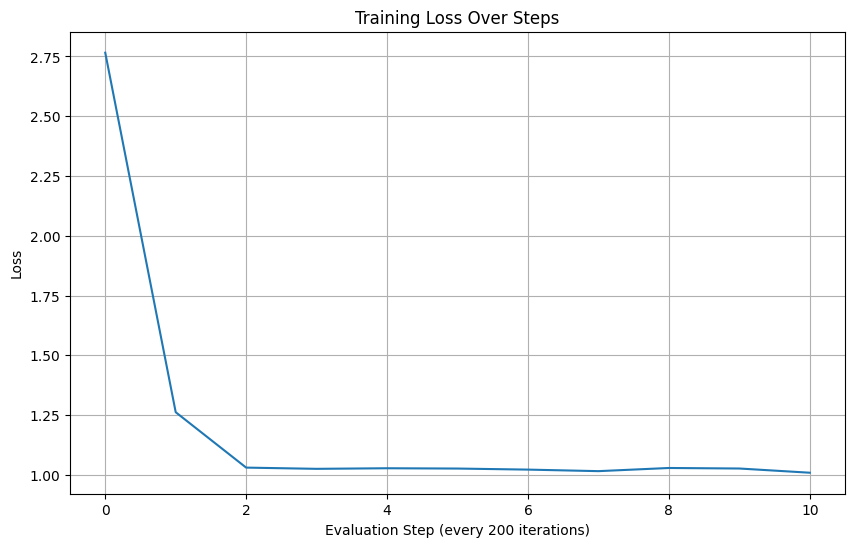

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title('Training Loss Over Steps')
plt.xlabel('Evaluation Step (every 200 iterations)')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Milestone 4 — Autoregressive Generation

## Goal

Generate text one token at a time.

The model should complete:

```text
12+35=
```

with:

```text
47
```

# Step 1 — Generation Function

In [17]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens=10, temperature=1.0):

    model.eval()

    idx = torch.tensor([encode(start_text)], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]

        # Greedy decoding: always pick the highest-probability token.
        # This removes all randomness from evaluation so the score is
        # deterministic and reflects the model's best guess every time.
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)

    return decode(idx[0].tolist())

In [27]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens=10, temperature=1.0):

    model.eval()

    # Encode input
    idx = torch.tensor([encode(start_text)], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):

        # Crop context window
        idx_cond = idx[:, -block_size:]

        # Forward pass
        logits, _ = model(idx_cond)

        # Take last token logits
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample next token using torch.multinomial
        idx_next = torch.multinomial(probs, num_samples=1)

        # Append prediction to sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return decode(idx[0].tolist())

# Step 2 — Test Generation

In [28]:
print(generate(model, '12+35='))
print(generate(model, '99+18='))
print(generate(model, '384+217='))

12+35=047
29+45=
99+18=117
03+35=
384+217=0
78+742+7


# Final Evaluation Milestone

## Goal

Achieve:

- >=95% accuracy on unseen 2-digit problems
OR
- >=95% accuracy on unseen 3-digit problems

# Mathematical Evaluation

This evaluation checks REAL arithmetic correctness.

The model only passes if:

1. Output parses correctly
2. Prediction equals actual sum

# Student Task

Complete all TODO sections.

Then run the evaluation block below.

# Self-Grading Block

In [29]:
import re


def extract_answer(text):

    # Extract digits after '=' and strip leading zeros for comparison
    match = re.search(r'=([0-9]+)', text)

    if match:
        return str(int(match.group(1)))   # int() removes leading zeros from zero-padded answers

    return None


@torch.no_grad()
def evaluate_model(model, num_tests=200, max_digits=2):

    model.eval()

    correct = 0

    examples = []

    for _ in range(num_tests):

        a = random.randint(0, 10**max_digits - 1)
        b = random.randint(0, 10**max_digits - 1)

        # Zero-padded prompt to match training data format (e.g. "03+76=")
        prompt = f'{a:0{max_digits}d}+{b:0{max_digits}d}='

        generated = generate(
            model,
            prompt,
            max_new_tokens=max_digits + 3,
            temperature=0.1
        )

        predicted = extract_answer(generated)

        expected = str(a + b)

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        examples.append({
            'prompt': prompt,
            'prediction': predicted,
            'expected': expected,
            'correct': is_correct
        })

    accuracy = correct / num_tests

    return accuracy, examples

  # =====================================================
# SELF-GRADING CHECKLIST
# =====================================================

score = 0
max_score = 100

print('\n===============================')
print('AUTOGRADER RESULTS')
print('===============================\n')

# -----------------------------------------------------
# CHECK 1 — Tokenizer
# -----------------------------------------------------

try:
    encoded = encode('12+7=19')
    decoded = decode(encoded)

    if decoded == '12+7=19':
        print('[PASS] Tokenizer encode/decode works')
        score += 15
    else:
        print('[FAIL] Tokenizer mismatch')

except Exception as e:
    print('[FAIL] Tokenizer crashed:', e)


# -----------------------------------------------------
# CHECK 2 — Batch Generation
# -----------------------------------------------------

try:
    X, Y = get_batch()

    if X.shape == Y.shape:
        print('[PASS] Batch generation works')
        score += 15
    else:
        print('[FAIL] Batch shapes incorrect')

except Exception as e:
    print('[FAIL] Batch generation crashed:', e)


# -----------------------------------------------------
# CHECK 3 — Attention Layer
# -----------------------------------------------------

try:
    test_head = Head(64, 16).to(device)

    x = torch.randn(4, block_size, 64).to(device)

    out = test_head(x)

    if out.shape[0] == 4:
        print('[PASS] Attention head runs')
        score += 20
    else:
        print('[FAIL] Attention output incorrect')

except Exception as e:
    print('[FAIL] Attention layer crashed:', e)


# -----------------------------------------------------
# CHECK 4 — Model Forward Pass
# -----------------------------------------------------

try:
    xb, yb = get_batch()

    logits, loss = model(xb, yb)

    if logits.shape[0] == xb.shape[0]:
        print('[PASS] Model forward pass works')
        score += 20
    else:
        print('[FAIL] Model logits incorrect')

except Exception as e:
    print('[FAIL] Model forward pass crashed:', e)


# -----------------------------------------------------
# CHECK 5 — Arithmetic Accuracy
# -----------------------------------------------------

try:
    accuracy, examples = evaluate_model(
        model,
        num_tests=100,
        max_digits=2
    )

    print(f'\n2-digit accuracy: {accuracy:.2%}')

    if accuracy >= 0.95:
        print('[PASS] Achieved >=95% accuracy')
        score += 30
    else:
        print('[FAIL] Accuracy below 95%')

    print('\nExample predictions:\n')

    for ex in examples[:10]:
        print(ex)

except Exception as e:
    print('[FAIL] Evaluation crashed:', e)


# =====================================================
# FINAL SCORE
# =====================================================

print('\n===============================')
print(f'FINAL SCORE: {score}/{max_score}')
print('===============================\n')

if score == 100:
    print('Excellent work — your Tiny Transformer learned arithmetic.')
elif score >= 80:
    print('Good job — most Transformer components work correctly.')
else:
    print('Review the TODO sections and debug carefully.')


AUTOGRADER RESULTS

[PASS] Tokenizer encode/decode works
[PASS] Batch generation works
[PASS] Attention head runs
[PASS] Model forward pass works

2-digit accuracy: 100.00%
[PASS] Achieved >=95% accuracy

Example predictions:

{'prompt': '70+25=', 'prediction': '95', 'expected': '95', 'correct': True}
{'prompt': '74+87=', 'prediction': '161', 'expected': '161', 'correct': True}
{'prompt': '16+84=', 'prediction': '100', 'expected': '100', 'correct': True}
{'prompt': '19+53=', 'prediction': '72', 'expected': '72', 'correct': True}
{'prompt': '30+92=', 'prediction': '122', 'expected': '122', 'correct': True}
{'prompt': '00+26=', 'prediction': '26', 'expected': '26', 'correct': True}
{'prompt': '06+63=', 'prediction': '69', 'expected': '69', 'correct': True}
{'prompt': '64+96=', 'prediction': '160', 'expected': '160', 'correct': True}
{'prompt': '29+80=', 'prediction': '109', 'expected': '109', 'correct': True}
{'prompt': '63+08=', 'prediction': '71', 'expected': '71', 'correct': True}

F

# Stretch Goals

If you finish early:

1. Add dropout
2. Add learning-rate scheduling
3. Train on subtraction
4. Add multiplication
5. Compare greedy decoding vs sampling
6. Visualize attention maps
7. Train on 4-digit addition
8. Add teacher forcing experiments
9. Implement KV caching
10. Compare parameter counts vs accuracy

# Suggested Hyperparameters

These are known-good starter values:

```python
batch_size = 32
block_size = 32
n_embd = 64
n_head = 4
n_layer = 2
learning_rate = 1e-3
max_iters = 3000
```

# Submission Requirements

Submit:

1. Completed notebook
2. Final autograder score
3. Screenshot of generated examples
4. Short explanation:
   - What was hardest?
   - What debugging strategy worked best?
   - What surprised you about Transformers?

# Important Conceptual Questions

You should be able to explain:

1. Why is the causal mask necessary?
2. Why do we shift targets by one token?
3. Why do we add positional embeddings?
4. Why do residual connections help?
5. Why does the model eventually learn carrying operations?
6. Why is addition a sequence modeling problem?
7. What happens if the block size is too small?

# Recommended Debugging Strategy

1. First verify tokenizer correctness
2. Then verify batches
3. Then verify attention dimensions
4. Then verify loss decreases
5. Finally test arithmetic correctness

Do not attempt to debug the full model all at once.

# Expected Results

Typical training progression:

```text
step 0     loss ~2.5
step 500   loss ~1.2
step 1500  loss ~0.4
step 3000  loss ~0.1
```

Final 2-digit accuracy:

```text
95% - 100%
```

# Final Reflection

This assignment demonstrates a profound idea:

A Transformer trained only on next-character prediction can learn an algorithmic process like arithmetic.

No calculator rules were explicitly programmed.

The model discovers the structure of addition from examples.